Deploying Vision Transformer on cuda
Loading ViT-Base-16 (Pre-trained)
Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:01<00:00, 189MB/s] 


Starting ViT Training


Epoch 10/10: 100%|██████████| 38/38 [00:51<00:00,  1.36s/it, Acc=61.83%]


ViT Model Saved: /content/drive/My Drive/DeepLense_GSoC_Data/vit_b_16_champion.pth
Running ViT Evaluation...


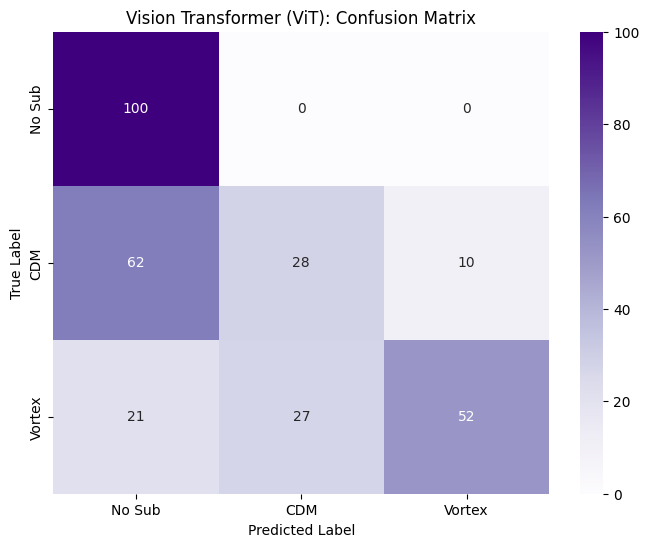


 ViT Final Report:
              precision    recall  f1-score   support

      No Sub       0.55      1.00      0.71       100
         CDM       0.51      0.28      0.36       100
      Vortex       0.84      0.52      0.64       100

    accuracy                           0.60       300
   macro avg       0.63      0.60      0.57       300
weighted avg       0.63      0.60      0.57       300

Extracting Probabilities for ROC Analysis
Professional ROC Curve saved to /content/drive/My Drive/DeepLense_GSoC_Data/assets/vit_roc_curve.png


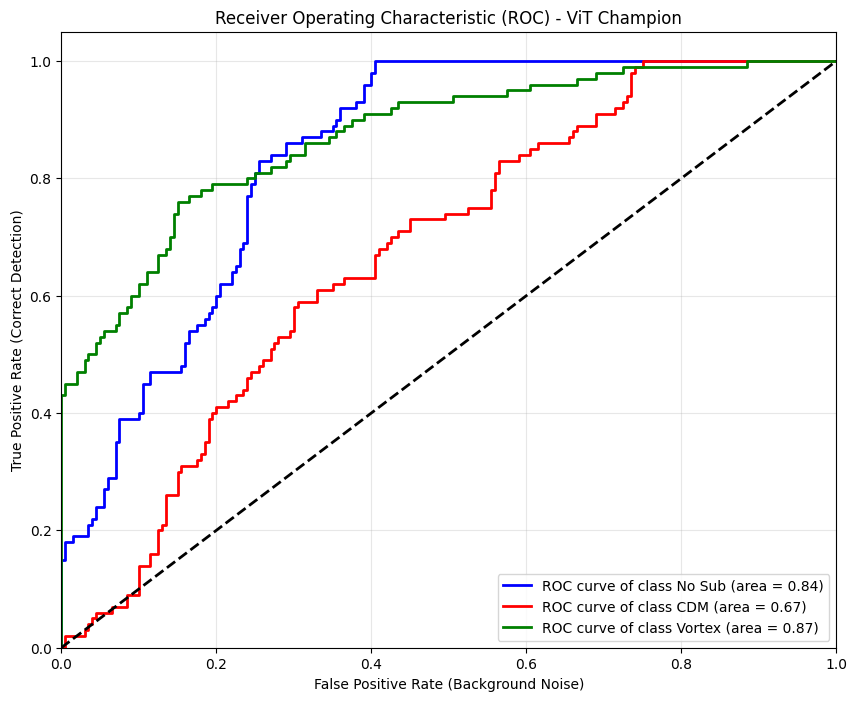

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
from torch.utils.data import DataLoader, Dataset
from PIL import Image
import pandas as pd
import os
from tqdm import tqdm
from sklearn.model_selection import train_test_split

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
base_dir = "/content/drive/My Drive/DeepLense_GSoC_Data"
print(f"Deploying Vision Transformer on {device}")

class DeepLenseDatasetViT(Dataset):
    def __init__(self, dataframe, root_dir, transform=None):
        self.dataframe = dataframe
        self.root_dir = root_dir
        self.transform = transform
        self.class_map = {'no_sub': 0, 'cdm': 1, 'vortex': 2}
    def __len__(self): return len(self.dataframe)
    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        img_path = os.path.join(self.root_dir, row['class'], row['filename'])
        image = Image.open(img_path).convert('RGB') 
        if self.transform: image = self.transform(image)
        return image, self.class_map[row['class']]

vit_transform = transforms.Compose([
    transforms.Resize((224, 224)), 
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

df = pd.read_csv(os.path.join(base_dir, "metadata.csv"))
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['class'])

train_loader = DataLoader(DeepLenseDatasetViT(train_df, base_dir, transform=vit_transform), batch_size=32, shuffle=True)
val_loader = DataLoader(DeepLenseDatasetViT(val_df, base_dir, transform=vit_transform), batch_size=32, shuffle=False)

print("Loading ViT-Base-16 (Pre-trained)")
model = models.vit_b_16(weights='IMAGENET1K_V1')
model.heads.head = nn.Linear(model.heads.head.in_features, 3) 
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=0.00005, weight_decay=0.01)
EPOCHS = 10 

print("Starting ViT Training")
for epoch in range(EPOCHS):
    model.train()
    correct = 0
    total = 0
    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")
    
    for images, labels in progress_bar:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        progress_bar.set_postfix({'Acc': f"{100 * correct / total:.2f}%"})

save_path = os.path.join(base_dir, "vit_b_16_champion.pth")
torch.save(model.state_dict(), save_path)
print(f"ViT Model Saved: {save_path}")

#EVALUATING THE NUCLEAR OPTION (ViT) 
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

model.eval()
all_preds = []
all_labels = []

print("Running ViT Evaluation...")
with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

classes = ['No Sub', 'CDM', 'Vortex']
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=classes, yticklabels=classes)
plt.title('Vision Transformer (ViT): Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
assets_dir = os.path.join(base_dir, "assets")
os.makedirs(assets_dir, exist_ok=True)
plt.savefig(os.path.join(assets_dir, "vit_confusion_matrix.png"), bbox_inches='tight', dpi=300)
plt.show()

print("\n ViT Final Report:")
print(classification_report(all_labels, all_preds, target_names=classes))

# ROC-AUC & W&B
import torch.nn.functional as F
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import numpy as np

all_probs = []
all_labels_roc = []

print("Extracting Probabilities for ROC Analysis")
model.eval()
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        probs = F.softmax(outputs, dim=1)
        
        all_probs.extend(probs.cpu().numpy())
        all_labels_roc.extend(labels.numpy())

all_probs = np.array(all_probs)
all_labels_roc = np.array(all_labels_roc)

y_test_bin = label_binarize(all_labels_roc, classes=[0, 1, 2])
n_classes = y_test_bin.shape[1]

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], all_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(10, 8))
colors = ['blue', 'red', 'green']
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'ROC curve of class {classes[i]} (area = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Background Noise)')
plt.ylabel('True Positive Rate (Correct Detection)')
plt.title('Receiver Operating Characteristic (ROC) - ViT Champion')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

assets_dir = os.path.join(base_dir, "assets")
os.makedirs(assets_dir, exist_ok=True)
save_path = os.path.join(assets_dir, "vit_roc_curve.png")
plt.savefig(save_path, bbox_inches='tight', dpi=300)
print(f"Professional ROC Curve saved to {save_path}")
plt.show()